In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass

sigma = 0.2
r = 0.05
T = 1.0
K = 100.0
S_max = 3 * K  # 300
M = 200  


In [10]:
def bs_call_price(S, K, r, sigma, tau):
    S = np.asarray(S, dtype=float)
    if tau <= 0:
        return np.maximum(S - K, 0.0)
    S_eff = np.maximum(S, 1e-12)
    vol = sigma * math.sqrt(tau)
    d1 = (np.log(S_eff / K) + (r + 0.5 * sigma**2) * tau) / vol
    d2 = d1 - vol
    Phi = lambda x: 0.5*(1.0 + math.erf(x / math.sqrt(2.0)))
    vPhi = np.vectorize(Phi)
    return S * vPhi(d1) - K * math.exp(-r * tau) * vPhi(d2)

@dataclass
class Grid:
    M: int
    N: int
    S: np.ndarray
    tau: np.ndarray
    dS: float
    dtau: float

def build_grid(S_max, T, M, sigma=0.2, r=0.05):
    dS = S_max / M
    dtau1 = (dS / S_max)**2 / (sigma**2)        
    dtau2 = dS / (r * S_max) if r > 0 else 1e9   
    dtau3 = 1.0 / r if r > 0 else 1e9           
    dtau_cfl = min(dtau1, dtau2, dtau3)
    dtau = 0.8 * dtau_cfl 
    N = int(math.ceil(T / dtau))
    dtau = T / N
    S = np.linspace(0.0, S_max, M + 1)
    tau = np.linspace(0.0, T, N + 1)
    return Grid(M=M, N=N, S=S, tau=tau, dS=dS, dtau=dtau), (dtau1, dtau2, dtau3, dtau)


In [11]:
def solve_ftcs(grid: Grid, sigma=0.2, r=0.05, K=100.0, S_max=300.0):
    M, N, S, dS, dtau = grid.M, grid.N, grid.S, grid.dS, grid.dtau
    Vn = np.maximum(S - K, 0.0) 

    for n in range(N):
        tau_n = grid.tau[n]
        V_next = Vn.copy()

        V_next[0]  = 0.0
        V_next[-1] = S_max - K * math.exp(-r * tau_n)

        for i in range(1, M):
            Si = S[i]
            alpha = 0.5 * sigma**2 * Si**2
            beta  = r * Si
            d2 = (Vn[i+1] - 2.0*Vn[i] + Vn[i-1]) / (dS**2)
            d1 = (Vn[i+1] - Vn[i-1]) / (2.0 * dS)
            V_next[i] = Vn[i] + dtau * (alpha*d2 + beta*d1 - r*Vn[i])

        tau_np1 = grid.tau[n+1]
        V_next[0]  = 0.0
        V_next[-1] = S_max - K * math.exp(-r * tau_np1)
        Vn = V_next

    return Vn


In [12]:
def thomas_solver(l, d, u, b):

    n = len(d)
    for i in range(1, n):
        w = l[i] / d[i-1]
        d[i] = d[i] - w * u[i-1]
        b[i] = b[i] - w * b[i-1]
    x = np.zeros_like(b)
    x[-1] = b[-1] / d[-1]
    for i in range(n-2, -1, -1):
        x[i] = (b[i] - u[i] * x[i+1]) / d[i]
    return x

def solve_backward_euler(grid: Grid, sigma=0.2, r=0.05, K=100.0, S_max=300.0):
    M, N, S, dS, dtau = grid.M, grid.N, grid.S, grid.dS, grid.dtau
    Vn = np.maximum(S - K, 0.0)

    for n in range(N):
        tau_np1 = grid.tau[n+1]

        l = np.zeros(M-1)
        d = np.zeros(M-1)
        u = np.zeros(M-1)
        b = Vn[1:M].copy()

        for i in range(1, M):
            Si = S[i]
            A = 0.5 * sigma**2 * Si**2 / (dS**2) - 0.5 * r * Si / dS
            B = -(sigma**2 * Si**2) / (dS**2) - r
            C = 0.5 * sigma**2 * Si**2 / (dS**2) + 0.5 * r * Si / dS
            idx = i - 1
            d[idx] = 1.0 - dtau * B
            if i-1 >= 1:
                l[idx] = -dtau * A
            else:
                l[idx] = 0.0
            if i+1 <= M-1:
                u[idx] = -dtau * C
            else:
                u[idx] = 0.0

        V0 = 0.0
        VM = S_max - K * math.exp(-r * tau_np1)

        i = 1
        Si = S[i]
        A1 = 0.5 * sigma**2 * Si**2 / (dS**2) - 0.5 * r * Si / dS
        b[0] = b[0] + dtau * A1 * V0 

        i = M-1
        Si = S[i]
        CM1 = 0.5 * sigma**2 * Si**2 / (dS**2) + 0.5 * r * Si / dS
        b[-1] = b[-1] + dtau * CM1 * VM

        x = thomas_solver(l, d, u, b)

        V_next = np.zeros_like(Vn)
        V_next[0]  = V0
        V_next[-1] = VM
        V_next[1:M] = x
        Vn = V_next

    return Vn


In [13]:

grid, (dtau1, dtau2, dtau3, dtau_used) = build_grid(S_max, T, M, sigma=sigma, r=r)
print(f"Сетка: M={grid.M} (узлов {grid.M+1}), N={grid.N}, dS={grid.dS:.6f}, dt={grid.dtau:.8f}")
print("Оценки устойчивости (консервативные) для явной схемы:")
print("  dtau_diff <=", dtau1, " (диффузия)")
print("  dtau_conv <=", dtau2, " (конвекция)")
print("  dtau_reac <=", dtau3, " (реакция)")
print("Использованный шаг dt (tau) =", dtau_used)

V_ftcs = solve_ftcs(grid, sigma=sigma, r=r, K=K, S_max=S_max)
V_impl = solve_backward_euler(grid, sigma=sigma, r=r, K=K, S_max=S_max)
S = grid.S
V_exact = bs_call_price(S, K, r, sigma, T)
err_ftcs = np.abs(V_ftcs - V_exact)
err_impl = np.abs(V_impl - V_exact)
print("\n||Ошибка||_inf (FTCS) =", err_ftcs.max())
print("||Ошибка||_inf (Implicit) =", err_impl.max())


Сетка: M=200 (узлов 201), N=2001, dS=1.500000, dt=0.00049975
Оценки устойчивости (консервативные) для явной схемы:
  dtau_diff <= 0.0006249999999999999  (диффузия)
  dtau_conv <= 0.1  (конвекция)
  dtau_reac <= 20.0  (реакция)
Использованный шаг dt (tau) = 0.0004997501249375312

||Ошибка||_inf (FTCS) = 0.0014313794482439524
||Ошибка||_inf (Implicit) = 0.0021856185895976488


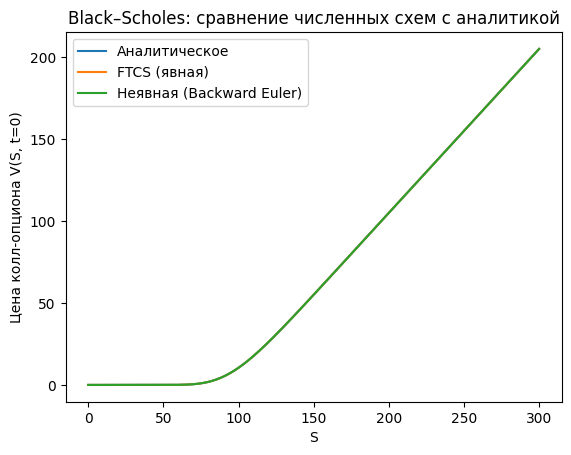

In [14]:

plt.figure()
plt.plot(S, V_exact, label="Аналитическое")
plt.plot(S, V_ftcs, label="FTCS (явная)")
plt.plot(S, V_impl, label="Неявная (Backward Euler)")
plt.xlabel("S")
plt.ylabel("Цена колл-опциона V(S, t=0)")
plt.title("Black–Scholes: сравнение численных схем с аналитикой")
plt.legend()
plt.show()


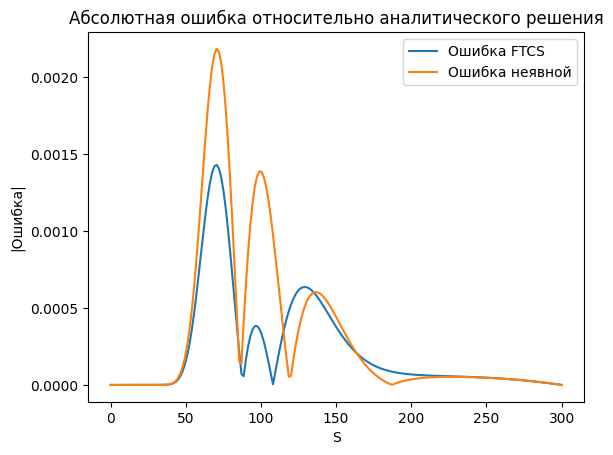

In [15]:

plt.figure()
plt.plot(S, np.abs(V_ftcs - V_exact), label="Ошибка FTCS")
plt.plot(S, np.abs(V_impl - V_exact), label="Ошибка неявной")
plt.xlabel("S")
plt.ylabel("|Ошибка|")
plt.title("Абсолютная ошибка относительно аналитического решения")
plt.legend()
plt.show()


In [16]:

import pandas as pd

def interp_price(S_query, S_grid, V_grid):
    return np.interp(S_query, S_grid, V_grid)

S_points = np.array([80.0, 100.0, 120.0])
rows = []
for s0 in S_points:
    rows.append({
        "S": s0,
        "Аналитическое": interp_price(s0, S, V_exact),
        "FTCS": interp_price(s0, S, V_ftcs),
        "Неявная": interp_price(s0, S, V_impl),
        "Ошибка FTCS": abs(interp_price(s0, S, V_ftcs) - interp_price(s0, S, V_exact)),
        "Ошибка неявной": abs(interp_price(s0, S, V_impl) - interp_price(s0, S, V_exact)),
    })
display(pd.DataFrame(rows).round(6))


,S,Аналитическое,FTCS,Неявная,Ошибка FTCS,Ошибка неявной
0,80.0,1.864096,1.864908,1.865337,0.000813,0.001241
1,100.0,10.455295,10.454955,10.453908,0.000340,0.001387
2,120.0,26.169044,26.169567,26.169103,0.000523,0.000059
